In [4]:
import pandas as pd
import glob
import json
import os

sample_path = f'{os.getcwd()}/../workspace/samples/'

x86_samples = 'x86-gemini-pro'
arm_samples = 'arm-gemini-pro'

def get_rows(path):

    summaries = sorted(glob.glob(f'{path}/*/agent_repair/summary.json'))
    experiment_results_path = f'{path}/results.json'

    with open(experiment_results_path, 'r') as f:
        experiment_results = json.load(f)
    
    sample_results = {
        sample['sample']: sample for sample in experiment_results['samples']
    }

    rows = []
    for sample, path in enumerate(summaries):

        with open(path, 'r') as f:
            data = json.load(f)
        
        arch = data['summary']['arch']

        total_input_tokens = data['llm_token_usage']['input_tokens']
        total_output_tokens = data['llm_token_usage']['output_tokens']
        total_total_tokens = data['llm_token_usage']['total_tokens']

        for attempt in data['attempts']:
            rows.append({
                'sample': sample,
                'arch': arch,
                'attempt': attempt['attempt'],
                'build_time': attempt['summary']['build_time'],
                'boot_time': attempt['summary']['boot_time'],
                'llm_time': attempt['summary']['llm_time'],
                'klocalizer_time': attempt['summary']['klocalizer_time'],
                'total_input_tokens': total_input_tokens,
                'total_output_tokens': total_output_tokens,
                'total_total_tokens': total_total_tokens,
                'input_tokens': attempt['token_usage']['input_tokens'],
                'output_tokens': attempt['token_usage']['output_tokens'],
                'total_tokens': attempt['token_usage']['total_tokens'],
                'wrapper_used': attempt['summary']['wrapper_used'],
                'sample_duration': sample_results[sample + 1]['duration'],
            })

    return rows

rows = get_rows(f'{sample_path}/{x86_samples}') + get_rows(f'{sample_path}/{arm_samples}')
df = pd.DataFrame(rows)

print(df.groupby('arch')['sample'].nunique())

df.head()

arch
arm64     50
x86_64    50
Name: sample, dtype: int64


,sample,arch,attempt,build_time,boot_time,llm_time,klocalizer_time,total_input_tokens,total_output_tokens,total_total_tokens,input_tokens,output_tokens,total_tokens,wrapper_used,sample_duration
0,0,x86_64,0,471.328610,0.000000,0.000000,NaN,3061379,102456,3163835,0,0,0,False,17831.86
1,0,x86_64,1,603.254357,303.257135,65.409955,129.0,3061379,102456,3163835,71915,3299,75214,False,17831.86
2,0,x86_64,2,135.539121,303.685512,25.788311,65.0,3061379,102456,3163835,6148,772,6920,False,17831.86
3,0,x86_64,3,517.567461,303.419052,438.815925,59.0,3061379,102456,3163835,228067,13119,241186,False,17831.86
4,0,x86_64,4,135.806998,303.332837,25.854099,66.0,3061379,102456,3163835,11258,1717,12975,False,17831.86


# Token Usage

In [6]:
# Per sample

arch_sample_group = df.groupby(['arch', 'sample'])
token_cols = ['total_input_tokens', 'total_output_tokens', 'total_total_tokens']

print('Arch split:')
print(arch_sample_group[token_cols].first().groupby('arch').describe().to_string())

print()

print('Overall:')
print(arch_sample_group[token_cols].first().reset_index(level='arch', drop=True).describe().to_string())

Arch split:
       total_input_tokens                                                                                  total_output_tokens                                                                         total_total_tokens                                                                                
                    count        mean           std       min        25%        50%         75%        max               count      mean           std      min       25%      50%       75%       max              count        mean           std       min       25%        50%         75%        max
arch                                                                                                                                                                                                                                                                                                     
arm64                50.0  1628047.20  1.481537e+06  154208.0  733213.25  1220579.0  2075750.7

In [10]:
# Per attempt

token_cols = ['input_tokens', 'output_tokens', 'total_tokens']

print(df[df['attempt'] > 0].groupby('arch')[token_cols].describe().to_string())

print()

print('Overall:')
print(df[df['attempt'] > 0][token_cols].describe().to_string())

       input_tokens                                                                               output_tokens                                                                      total_tokens                                                                                
              count           mean            std      min      25%       50%       75%       max         count         mean          std    min      25%     50%       75%      max        count           mean            std      min       25%       50%        75%       max
arch                                                                                                                                                                                                                                                                             
arm64         482.0  168884.564315  140250.153773  11600.0  57383.0  122523.5  252264.0  699058.0         482.0  6298.020747  4298.071998  461.0  3193.25  5428.5   7864.25  28753

# Time

In [12]:
times = df.groupby(['arch', 'sample']).agg(
        build=('build_time', 'sum'),
        boot=('boot_time', 'sum'),
        llm=('llm_time', 'sum'),
        krepair=('klocalizer_time', 'sum'),
        total=('sample_duration', 'first')
    ) / 60 / 60

times['other'] = times['total'] - times[['build', 'boot', 'llm', 'krepair']].sum(axis=1)
times = times.reset_index()

times_cols = ['build', 'boot', 'llm', 'krepair', 'other', 'total']

print(times.groupby('arch')[times_cols].describe().to_string())

print()

print('Overall:')
print(times[times_cols].describe().to_string())

       build                                                                         boot                                                                         llm                                                                       krepair                                                                       other                                                                         total                                                                       
       count      mean       std       min       25%       50%       75%        max count      mean       std       min       25%       50%       75%       max count      mean       std       min       25%       50%       75%       max   count      mean       std       min       25%       50%       75%       max count      mean       std        min       25%       50%       75%        max count      mean       std       min       25%       50%       75%        max
arch                                                          

/var/folders/pr/nv_v3rqd08n1m2tvy5dhq3y40000gn/T/ipykernel_69674/189915074.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = f'{labels[i]}: {percentages[i]}%'


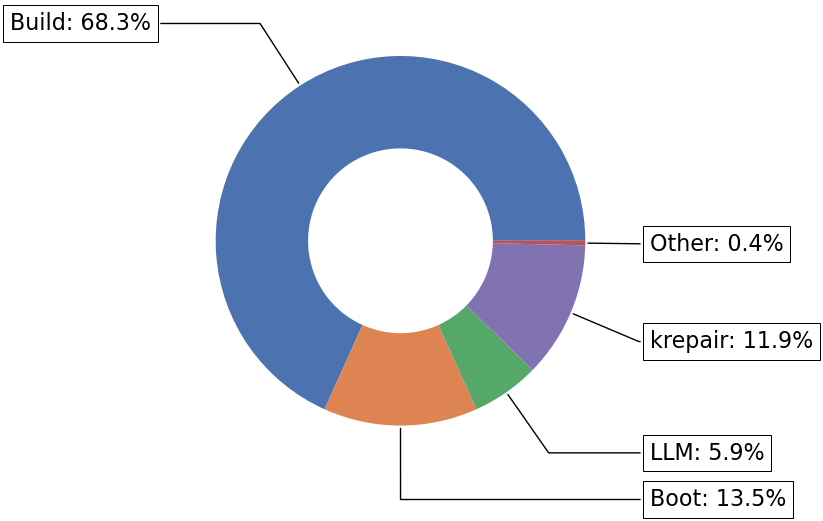

In [14]:
from matplotlib import pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

labels = ['Build', 'Boot', 'LLM', 'krepair', 'Other']
colors = ['#4C72B0', '#DD8452', '#55A868', '#8172B2', '#C44E52']

bbox_props = dict(boxstyle='square,pad=0.3', fc='w', ec='k', lw=0.72)
kw = dict(arrowprops=dict(arrowstyle='-'), bbox=bbox_props, zorder=0, va='center')

wedges, _ = ax.pie(times[['build', 'boot', 'llm', 'krepair', 'other']].mean(), labels=None, wedgeprops=dict(width=0.5), colors=colors)

percentages = (times[['build', 'boot', 'llm', 'krepair', 'other']].mean() / total_time * 100).round(1)

for i, p in enumerate(wedges):
    theta = (p.theta2 - p.theta1) / 2. + p.theta1
    y = np.sin(np.deg2rad(theta))
    x = np.cos(np.deg2rad(theta))

    horizontalalignment = {-1: 'right', 1: 'left'}[int(np.sign(x))]
    connectionstyle = f'angle,angleA=0,angleB={theta}'
    kw['arrowprops'].update({'connectionstyle': connectionstyle})

    label = f'{labels[i]}: {percentages[i]}%'
    ax.annotate(label, xy=(x, y), xytext=(1.35 * np.sign(x), 1.4 * y), horizontalalignment=horizontalalignment, **kw, fontsize=16)

plt.savefig('time-distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()